In [1]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

print("Train:", train_df.shape)
print("Val:",   val_df.shape)
print("Test:",  test_df.shape)

train_df.head()

Train: (29358, 6)
Val: (6291, 6)
Test: (6291, 6)


,clean_text,label,brunet_w,proper_nouns_count,singular_words_count,entity_diversity
0,يتناول البحث ابعاد الامن الانساني القانون التو...,1,33.216682,1,25,1.000000
1,النص الشعري الذي يتميز بالقدره علي استخدام الم...,1,42.465845,4,35,1.000000
2,ملخص يتناول البحث موضوع الخلع وشروطه واثاره بي...,1,51.706150,13,68,0.538462
3,يتناول البحث التزام العون الاقتصادي بضروره الا...,1,65.364308,5,64,0.400000
4,تستكشف الورقه البحثيه مبدا افتراض البراءه القا...,1,34.768221,6,35,0.500000


In [2]:
feature_cols = ["brunet_w", "proper_nouns_count", "singular_words_count", "entity_diversity"]

X_train = train_df[feature_cols]
y_train = train_df["label"]

X_val = val_df[feature_cols]
y_val = val_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

X_train.shape, X_val.shape, X_test.shape

((29358, 4), (6291, 4), (6291, 4))

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=140, random_state=42),
    "Linear SVM": LinearSVC(),
    

    "MLP (Features)": Pipeline([
        ("scaler", StandardScaler()),  
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42,
            early_stopping=True,
            n_iter_no_change=10
        ))
    ])
}

val_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_val_pred = model.predict(X_val)
    acc  = accuracy_score(y_val, y_val_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average="weighted"
    )

    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_scores)
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_val)
            auc = roc_auc_score(y_val, y_scores)
        else:
            auc = None
    except Exception:
        auc = None
    
    val_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    })

val_results_df = pd.DataFrame(val_results).sort_values("Accuracy", ascending=False)
val_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.930536,0.933875,0.930536,0.931725,0.952774
3,MLP (Features),0.813384,0.782912,0.813384,0.774557,0.789066
0,Logistic Regression,0.805913,0.769113,0.805913,0.744186,0.734403
2,Linear SVM,0.804006,0.775636,0.804006,0.728124,0.735712


In [4]:
best_row = val_results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]

print("Best model selected based on Validation Accuracy:")
print(best_row)
best_model_name

Best model selected based on Validation Accuracy:
Model        Random Forest
Accuracy          0.930536
Precision         0.933875
Recall            0.930536
F1                0.931725
ROC_AUC           0.952774
Name: 1, dtype: object


'Random Forest'

In [5]:
import numpy as np

best_model = models[best_model_name]

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_train_val, y_train_val)

print("Best model retrained on Train + Val:", best_model_name)

Best model retrained on Train + Val: Random Forest


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test)
acc  = accuracy_score(y_test, y_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="weighted")

try:
    if hasattr(best_model, "predict_proba"):
        y_scores = best_model.predict_proba(X_test)[:, 1]
    else:
        y_scores = best_model.decision_function(X_test)
    auc = roc_auc_score(y_test, y_scores)
except Exception:
    auc = None

print("Final Test Evaluation")
print("Best model:", best_model_name)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Test Evaluation
Best model: Random Forest
Accuracy: 0.9507232554442855
Precision: 0.9568970586277503
Recall: 0.9507232554442855
F1-score: 0.9521881079499035
ROC-AUC: 0.9834215007658516

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1258
           1       0.99      0.95      0.97      5033

    accuracy                           0.95      6291
   macro avg       0.91      0.96      0.93      6291
weighted avg       0.96      0.95      0.95      6291

Confusion Matrix:
[[1216   42]
 [ 268 4765]]



=== Confusion Matrix: Logistic Regression ===
[[ 107 1151]
 [ 106 4927]]


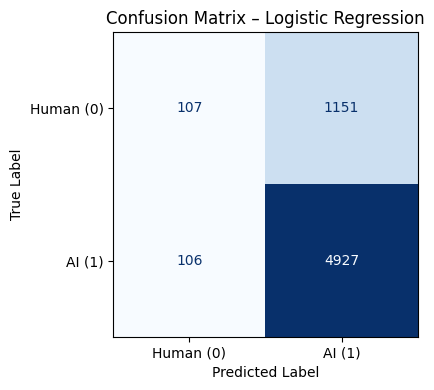


=== Confusion Matrix: Random Forest ===
[[1216   42]
 [ 268 4765]]


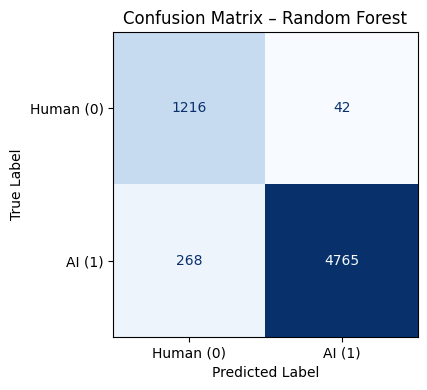


=== Confusion Matrix: Linear SVM ===
[[  55 1203]
 [  33 5000]]


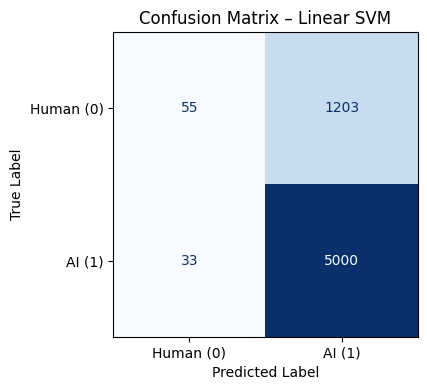


=== Confusion Matrix: MLP (Features) ===
[[ 285  973]
 [ 193 4840]]


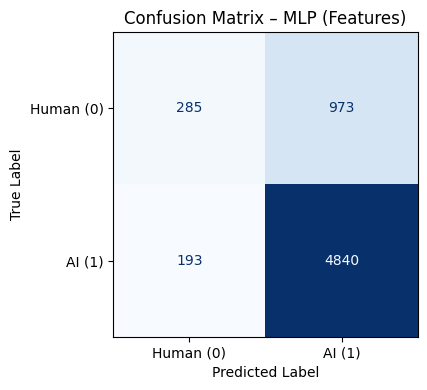

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    print(f"\n=== Confusion Matrix: {name} ===")

    # Select correct test input
    if name == "MLP (BERT Embeddings)":
        y_pred = model.predict(X_test_emb)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Human (0)", "AI (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [8]:
test_with_preds = test_df.copy()
test_with_preds["y_true"] = y_test
test_with_preds["y_pred"] = y_test_pred

human_as_ai = test_with_preds[(test_with_preds["y_true"] == 0) & (test_with_preds["y_pred"] == 1)]
ai_as_human = test_with_preds[(test_with_preds["y_true"] == 1) & (test_with_preds["y_pred"] == 0)]

print("Human texts misclassified as AI:", human_as_ai.shape[0])
print("AI texts misclassified as Human:", ai_as_human.shape[0])

human_as_ai[["clean_text", "y_true", "y_pred"]].head(5)

Human texts misclassified as AI: 42
AI texts misclassified as Human: 268


,clean_text,y_true,y_pred
334,ان اقتحام المراه العربيه مختلف مجالات الثقافه ...,0,1
500,يعتبر مبدا الافصاح والشفافيه المبادي الاساسيه ...,0,1
550,هتمت الدراسات النصيه الحديثه والقديمه باليه ال...,0,1
647,تعد تجاره المقايضه الحدوديه اليه تشريعيه لتنمي...,0,1
658,يحلل البحث الخطاب السياسي العراقي ويناقش امكان...,0,1


In [9]:
import joblib
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(project_root, "model")
os.makedirs(model_dir, exist_ok=True)

best_model_name = val_results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

model_path = os.path.join(model_dir, f"{best_model_name.replace(' ', '_').lower()}_best_model.joblib")

joblib.dump(best_model, model_path)

print("Saved to:", model_path)
print("File exists? ", os.path.exists(model_path))

Saved to: /Users/m.abuselmi/PycharmProjects/MSIS822_Project/model/random_forest_best_model.joblib
File exists?  True
